In [14]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib
# matplotlib.use('agg')
import matplotlib.pyplot as plt
# 【关键两行】——必须同时设置！
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'PingFang SC', 'Heiti TC', 'WenQuanYi Micro Hei']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号 '-' 显示为方块的问题[1][2][3][4][5][6][7][8][9][10]

import os
# from tqdm.notebook import  tqdm
from tqdm import  tqdm
import talib
import datetime
import math
import  mplfinance as mpf

import sys
sys.path.append('../../DataSource/聚宽数据')
import datasource 
sys.path.append('../..')
import Utils
# 这个是筛选多少天上涨多少的，
codes = datasource.getAStockCodes()
print(f'股票数量:{len(codes)},第一支股票:{codes[0]}')
code = codes[0]
dt = datasource.getData(code)
dt.head()

股票数量:4929,第一支股票:000001.XSHE


index  open  high   low  close         money  \
code        date                                                       
000001.XSHE 2018-06-20      0  7.55  7.62  7.47   7.59  7.529507e+08   
            2018-06-21      1  7.60  7.68  7.55   7.55  8.360148e+08   
            2018-06-22      2  7.50  7.55  7.48   7.54  6.457529e+08   
            2018-06-25      3  7.59  7.59  7.18   7.24  1.154559e+09   
            2018-06-26      4  7.19  7.23  6.96   7.16  1.042529e+09   

                             volume  
code        date                     
000001.XSHE 2018-06-20   99764990.0  
            2018-06-21  109750599.0  
            2018-06-22   85940350.0  
            2018-06-25  156147915.0  
            2018-06-26  146864886.0

In [15]:
dt['date']=dt.index.get_level_values('date')

In [16]:
dt.head()

index  open  high   low  close         money  \
code        date                                                       
000001.XSHE 2018-06-20      0  7.55  7.62  7.47   7.59  7.529507e+08   
            2018-06-21      1  7.60  7.68  7.55   7.55  8.360148e+08   
            2018-06-22      2  7.50  7.55  7.48   7.54  6.457529e+08   
            2018-06-25      3  7.59  7.59  7.18   7.24  1.154559e+09   
            2018-06-26      4  7.19  7.23  6.96   7.16  1.042529e+09   

                             volume       date  
code        date                                
000001.XSHE 2018-06-20   99764990.0 2018-06-20  
            2018-06-21  109750599.0 2018-06-21  
            2018-06-22   85940350.0 2018-06-22  
            2018-06-25  156147915.0 2018-06-25  
            2018-06-26  146864886.0 2018-06-26

In [17]:
dt['week_day_num'] = dt['date'].dt.day_of_week
dt.head()
# 星期一是0，以此类推。

index  open  high   low  close         money  \
code        date                                                       
000001.XSHE 2018-06-20      0  7.55  7.62  7.47   7.59  7.529507e+08   
            2018-06-21      1  7.60  7.68  7.55   7.55  8.360148e+08   
            2018-06-22      2  7.50  7.55  7.48   7.54  6.457529e+08   
            2018-06-25      3  7.59  7.59  7.18   7.24  1.154559e+09   
            2018-06-26      4  7.19  7.23  6.96   7.16  1.042529e+09   

                             volume       date  week_day_num  
code        date                                              
000001.XSHE 2018-06-20   99764990.0 2018-06-20             2  
            2018-06-21  109750599.0 2018-06-21             3  
            2018-06-22   85940350.0 2018-06-22             4  
            2018-06-25  156147915.0 2018-06-25             0  
            2018-06-26  146864886.0 2018-06-26             1

In [18]:
dt['pre_close']=dt['close'].shift(1) # 昨天的收盘价
dt['next_close'] = dt['close'].shift(-1) # 明天的收盘价
dt['pct_change']= (dt['close']-dt['pre_close'])/dt['pre_close']*100 # 昨天到今天的涨幅
dt['next_pct_change']=dt['pct_change'].shift(-1) # 明天到今天的涨幅
dt.head()

index  open  high   low  close         money  \
code        date                                                       
000001.XSHE 2018-06-20      0  7.55  7.62  7.47   7.59  7.529507e+08   
            2018-06-21      1  7.60  7.68  7.55   7.55  8.360148e+08   
            2018-06-22      2  7.50  7.55  7.48   7.54  6.457529e+08   
            2018-06-25      3  7.59  7.59  7.18   7.24  1.154559e+09   
            2018-06-26      4  7.19  7.23  6.96   7.16  1.042529e+09   

                             volume       date  week_day_num  pre_close  \
code        date                                                          
000001.XSHE 2018-06-20   99764990.0 2018-06-20             2        NaN   
            2018-06-21  109750599.0 2018-06-21             3       7.59   
            2018-06-22   85940350.0 2018-06-22             4       7.55   
            2018-06-25  156147915.0 2018-06-25             0       7.54   
            2018-06-26  146864886.0 2018-06-26             1       7.24   

                        next_close  pct_change  next_pct_change  
code        date                                                 
000001.XSHE 2018-06-20        7.55         NaN        -0.527009  
            2018-06-21        7.54   -0.527009        -0.132450  
            2018-06-22        7.24   -0.132450        -3.978780  
            2018-06-25        7.16   -3.978780        -1.104972  
            2018-06-26        6.96   -1.104972        -2.793296

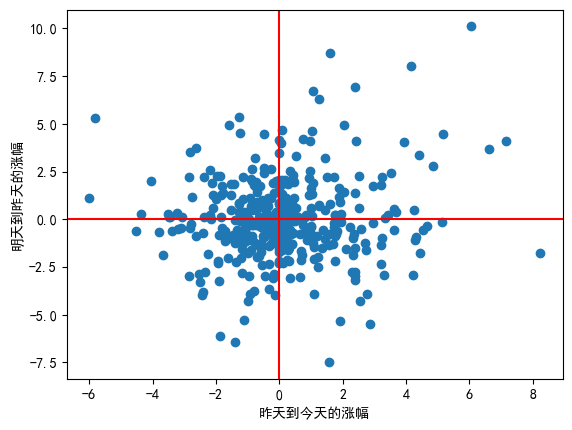

In [21]:
# 我这里看一下周五是什么情况
dt2 = dt.loc[dt['week_day_num'] == 4, : ] # 筛选周五的
# 然后画图，散点图，横轴是昨天到今天的涨幅，纵轴是明天到今天的涨幅
plt.scatter(dt2['pct_change'], dt2['next_pct_change'])
plt.xlabel('昨天到今天的涨幅')
plt.ylabel('明天到昨天的涨幅')
# 画横线和竖线
plt.axhline(0,color='red')
plt.axvline(0, color='red')

好像并没有看出什么相关的。